In [1]:
import pandas as pd
from scipy.io import mmread
import scipy.sparse
import scanpy as sc
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ranksums
from scipy import stats

In [2]:
scroot = '/work/users/k/r/kritis/single_cell/PRJNA679579'

In [3]:
X = mmread(f"{scroot}/GSE161824_A549_TP53.processed.matrix.mtx").tocsr()

In [4]:
# Load gene names and barcodes
genes = pd.read_csv(f"{scroot}/GSE161824_A549_TP53.processed.genes.csv", header=None)
barcodes = pd.read_csv(f"{scroot}/GSE161824_A549_TP53.processed.cells.csv", header=None)

In [5]:
import anndata as ad
adata = ad.AnnData(X)
adata.var_names = genes[0].values  # column 1 = gene symbols
adata.obs_names = barcodes[0].values

In [6]:
print(adata)

AnnData object with n_obs × n_vars = 85778 × 1224


In [7]:
# Calculate basic QC metrics
sc.pp.calculate_qc_metrics(adata, inplace=True)

# Filter cells: min genes, max counts, max % mitochondrial
adata = adata[adata.obs['n_genes_by_counts'] > 200, :]
adata = adata[adata.obs['total_counts'] < 25000, :]

/nas/longleaf/home/kritis/.local/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/nas/longleaf/home/kritis/.local/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [8]:
print(adata)

View of AnnData object with n_obs × n_vars = 85778 × 1224
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'


In [9]:
sc.pp.filter_genes(adata, min_cells=10)

/nas/longleaf/home/kritis/.local/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:283: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["n_cells"] = number


In [10]:
print(adata)

AnnData object with n_obs × n_vars = 85778 × 1224
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'


In [11]:
barcodes_mut = pd.read_csv('/work/users/k/r/kritis/database_analysis/TP53_example/HES2_barcodes.csv')

In [12]:
barcode_list = barcodes_mut['cell_barcode'].tolist()

In [13]:
adata.obs['mut'] = adata.obs_names.isin(barcode_list)
# Optional: make it clearer
adata.obs['mut'] = adata.obs['mut'].map({True: 'Target', False: 'Other'})

In [14]:
adata_target = adata[adata.obs['mut'] == 'Target'].copy()
adata_other = adata[adata.obs['mut'] == 'Other'].copy()

In [15]:
genes = pd.read_csv('/work/users/k/r/kritis/single_cell/PRJNA679579/TP53_HES2_example/genelist.csv')

In [16]:
gene_list = genes['0'].tolist()

In [17]:
gene_list = [g for g in gene_list if g in adata.var_names]
print(f"Using {len(gene_list)} genes from your list.")

Using 165 genes from your list.


In [18]:
X = adata[:, gene_list].X
if not isinstance(X, np.ndarray):
    X = X.toarray()  # in case it's sparse

avg_expr = X.mean(axis=1)
adata.obs['gene_signature_avg'] = avg_expr

/tmp/ipykernel_3898320/386510469.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=adata.obs, x='mut', y='gene_signature_avg', inner='box', palette='pastel')


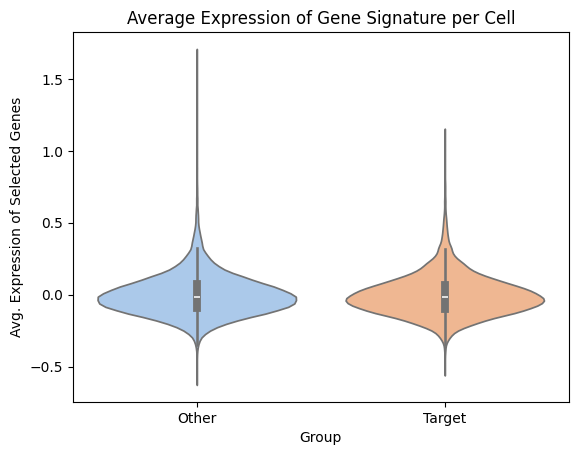

In [19]:
sns.violinplot(data=adata.obs, x='mut', y='gene_signature_avg', inner='box', palette='pastel')
plt.title('Average Expression of Gene Signature per Cell')
plt.ylabel('Avg. Expression of Selected Genes')
plt.xlabel('Group')
plt.show()

<Axes: xlabel='mut', ylabel='gene_signature_avg'>

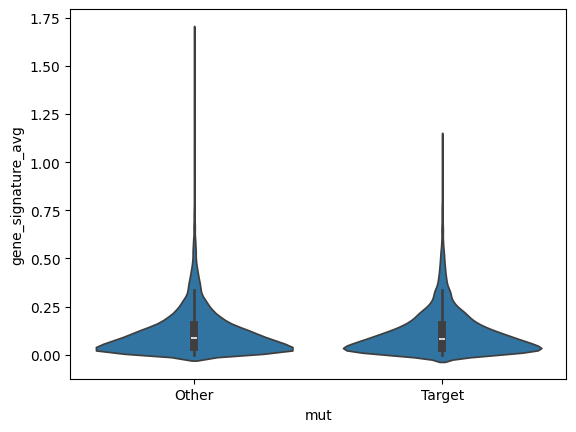

In [20]:
expressing = (adata[:, gene_list].X.toarray().sum(axis=1) > 0)
adata.obs['expressing_signature'] = np.where(expressing, 'Expressing', 'Not expressing')

# Then plot just the expressing ones
sns.violinplot(data=adata.obs[expressing], x='mut', y='gene_signature_avg')

In [21]:
target_expr = adata.obs.loc[adata.obs['mut'] == 'Target', 'gene_signature_avg']
other_expr = adata.obs.loc[adata.obs['mut'] == 'Other', 'gene_signature_avg']

print("Means:", target_expr.mean(), other_expr.mean())
print("Medians:", target_expr.median(), other_expr.median())
print("Std Devs:", target_expr.std(), other_expr.std())

Means: -0.0039197730891660015 -0.0014438111323767792
Medians: -0.01874344241363636 -0.015770224515151518
Std Devs: 0.14180598890980242 0.14300981551195183


In [22]:
group_1 = adata.obs[adata.obs['mut'] == 'Target']['gene_signature_avg']
group_2 = adata.obs[adata.obs['mut'] == 'Other']['gene_signature_avg']

stat, pval = ranksums(group_1.dropna(), group_2.dropna())
print(f'Wilcoxon p-value: {pval}')

Wilcoxon p-value: 0.02176332274702278


In [23]:
t_stat, p_value = stats.ttest_ind(group_1.dropna(), group_2.dropna())
print("T statistic:", t_stat)
print("T-test p-value:", p_value)

T statistic: -2.20321877023941
T-test p-value: 0.02758198129435602


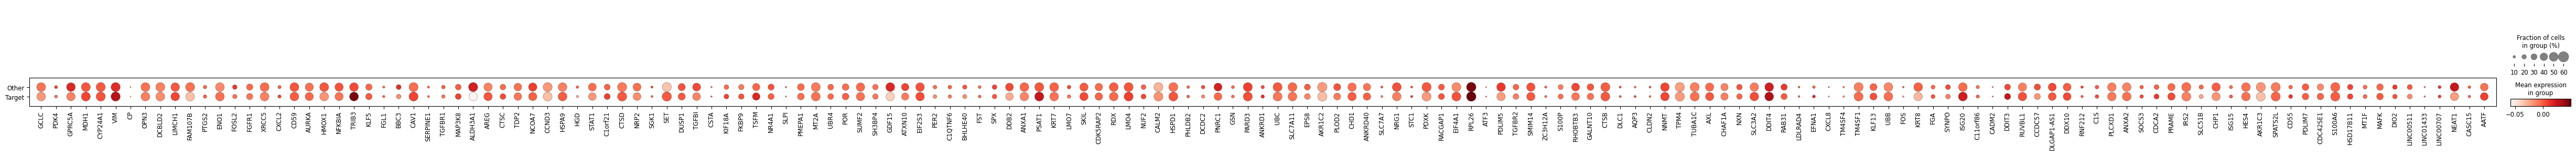

In [24]:
sc.pl.dotplot(adata, var_names=gene_list, groupby='mut')

In [25]:
is_target = adata.obs['mut'] == 'Target'
is_other = adata.obs['mut'] == 'Other'

# Define full gene sets
all_genes = adata.var_names.tolist()
not_gene_list = list(set(all_genes) - set(gene_list))

def avg_expr(genes, cells):
    X = adata[cells, genes].X
    if not isinstance(X, np.ndarray):
        X = X.toarray()
    return X.mean()

data = []

for group_name, mask in [('Target', is_target), ('Other', is_other)]:
    # In gene list
    mean_in_list = avg_expr(gene_list, mask)
    # Not in gene list
    mean_not_in_list = avg_expr(not_gene_list, mask)

    data.append({'Group': group_name, 'Subset': 'In gene list', 'Mean': mean_in_list})
    data.append({'Group': group_name, 'Subset': 'Not in gene list', 'Mean': mean_not_in_list})

df = pd.DataFrame(data)

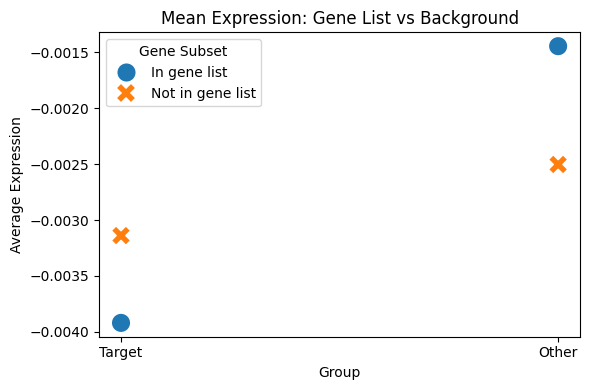

In [26]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='Group', y='Mean', hue='Subset', s=200, style='Subset')

# Optional: improve layout
plt.title('Mean Expression: Gene List vs Background')
plt.ylabel('Average Expression')
plt.legend(title='Gene Subset')
plt.tight_layout()
plt.show()

In [27]:
sc.tl.rank_genes_groups(adata, groupby='mut', groups=['Target'], reference='Other', method='wilcoxon')

/nas/longleaf/home/kritis/.local/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


In [28]:
sc.get.rank_genes_groups_df(adata, group='Target')

,names,scores,logfoldchanges,pvals,pvals_adj
0,HIST2H2BE,7.368357,NaN,1.727432e-13,3.020538e-11
1,RASSF10,7.282773,NaN,3.270268e-13,4.523190e-11
2,LDLRAD4,7.280499,-1.602722,3.325875e-13,4.523190e-11
3,HHIP-AS1,6.848704,NaN,7.452195e-12,8.292260e-10
4,ITGA11,6.609318,-1.747571,3.860956e-11,3.938175e-09
...,...,...,...,...,...
1219,FDXR,-8.615104,NaN,6.987834e-18,1.710622e-15
1220,ALDH3A1,-10.908886,NaN,1.045296e-27,3.198605e-25
1221,CDKN1A,-11.332732,NaN,9.034148e-30,3.685933e-27
1222,PHLDA3,-11.410033,NaN,3.725854e-30,2.280222e-27


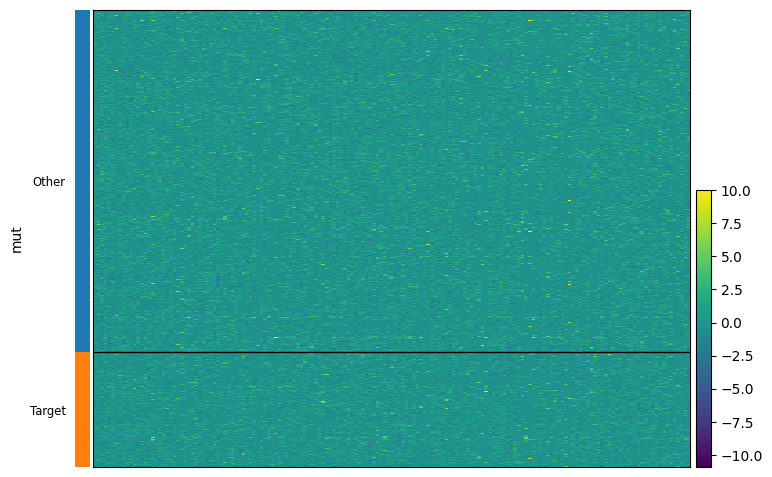

In [29]:
sc.pl.heatmap(adata, var_names=gene_list, groupby='mut', use_raw=False)

In [30]:
import numpy as np

# Convert sparse to dense if needed
X = adata[:, gene_list].X.toarray() if not isinstance(adata.X, np.ndarray) else adata[:, gene_list].X

# Create a DataFrame of expression values
import pandas as pd
expr_df = pd.DataFrame(X, columns=gene_list, index=adata.obs_names)
expr_df['mut'] = adata.obs['mut'].values

# Group by 'Target' and 'Other' and compute mean expression
signature_stats = expr_df.groupby('mut').mean()
print(signature_stats)

            GCLC      PDK4    GPRC5A      MDH1   CYP24A1       VIM        CP  \
mut                                                                            
Other  -0.007341  0.007871  0.017256  0.001460  0.000357  0.014917 -0.001107   
Target -0.019593 -0.005113 -0.012500  0.006877  0.001626  0.029819 -0.013127   

            OPN3    DCBLD2    LIMCH1  ...  HSD17B11      MT1F      MAFK  \
mut                                   ...                                 
Other  -0.007142 -0.012099  0.000904  ...  0.006062 -0.006173 -0.003842   
Target -0.011708 -0.016050  0.005427  ...  0.005915 -0.003093 -0.000079   

            DIO2  LINC00511  LINC01433  LINC00707     NEAT1    CASC15  \
mut                                                                     
Other   0.010012   0.000173  -0.006764   0.011978  0.024849 -0.000636   
Target  0.001858  -0.015295  -0.004140   0.009342 -0.021449 -0.004398   

            AATF  
mut               
Other  -0.007729  
Target  0.007797  

[2 rows 

/tmp/ipykernel_3898320/1533957719.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  signature_stats = expr_df.groupby('mut').mean()


In [31]:
gene_set = [g for g in gene_list if g in adata_target.var_names]

# All other genes
other_genes = [g for g in adata_target.var_names if g not in gene_set]

In [32]:
gene_idx = [adata_target.var_names.get_loc(g) for g in gene_set]
other_idx = [i for i in range(adata_target.shape[1]) if i not in gene_idx]

In [33]:
X = adata_target.X.toarray() if not isinstance(adata_target.X, np.ndarray) else adata_target.X

# Compute per-cell mean expression
sig_expr = X[:, gene_idx].mean(axis=1)
other_expr = X[:, other_idx].mean(axis=1)

/tmp/ipykernel_3898320/2016787389.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Gene Set', y='Average Expression', data=df_long, inner='box', palette='pastel')


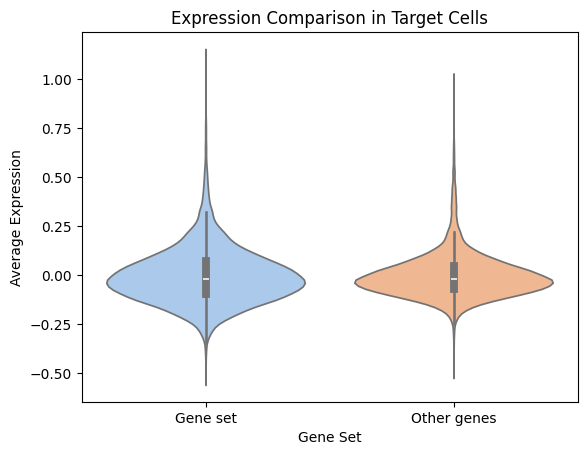

In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Tidy DataFrame
df_long = pd.DataFrame({
    'Gene set': sig_expr,
    'Other genes': other_expr
}).melt(var_name='Gene Set', value_name='Average Expression')

# Plot
sns.violinplot(x='Gene Set', y='Average Expression', data=df_long, inner='box', palette='pastel')
plt.title("Expression Comparison in Target Cells")
plt.show()

In [37]:
from scipy.stats import wilcoxon

stat, pval = wilcoxon(sig_expr, other_expr)
print(f"Wilcoxon p-value: {pval}")

Wilcoxon p-value: 0.0005502041771997309


In [36]:
t_stat, p_value = stats.ttest_ind(group_1.dropna(), group_2.dropna())
print("T statistic:", t_stat)
print("T-test p-value:", p_value)

T statistic: -2.20321877023941
T-test p-value: 0.02758198129435602
